
<a href="https://colab.research.google.com/github/CienciaDatosUdea/005_CCA_Estudiantes/blob/main/Laboratorios/09_Lab_Hopfield.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratorio: Memorias asociativas con redes de Hopfield

## Objetivo

Construir una red de Hopfield capaz de almacenar imágenes binarias y recuperar una imagen original a partir de una versión con ruido.


# Actividades

Para las imágenes dadas, construya un algoritmo que permita recuperar la imagen original a partir de una imagen perturbada.

Debe implementar funciones para:

1. Convertir una imagen binaria en un vector de estados.
2. Calcular la matriz de pesos de Hopfield.
3. Calcular el campo local que siente una neurona.
4. Actualizar el estado de una neurona.
5. Calcular la energía total de la red.
6. Aplicar ruido a una imagen.
7. Recuperar la imagen mediante actualización asincrónica aleatoria.

---

# Modelo de Hopfield

La matriz de pesos se define mediante la regla de Hebb:

$$
w_{ij}=\frac{1}{N}\sum_{\mu=1}^{P}\xi_i^\mu \xi_j^\mu
$$

con:

$$
w_{ii}=0
$$

donde:

- $N$ es el número total de píxeles,
- $P$ es el número de patrones almacenados,
- $\xi^\mu$ es el patrón $\mu$-ésimo.

---

# Campo local

Para una neurona $i$, el campo local es:

$$
h_i=\sum_j w_{ij}s_j
$$

Este campo representa la influencia colectiva que todas las demás neuronas ejercen sobre la neurona $i$.

---

# Regla de actualización

La actualización determinista de Hopfield es:

$$
s_i \leftarrow \mathrm{sign}(h_i)
$$

Si:

$$
h_i>0
$$

entonces:

$$
s_i=1
$$

Si:

$$
h_i<0
$$

entonces:

$$
s_i=-1
$$

---

# Energía de la red

La energía total del sistema se define como:

$$
E(s)=-\frac{1}{2}\sum_{ij}w_{ij}s_is_j
$$

o equivalentemente:

$$
E(s)=-\frac{1}{2}s^TWs
$$

El proceso de recuperación debe tender a disminuir la energía.

---

# Algoritmo sugerido

Dada una imagen con ruido:

1. Seleccione aleatoriamente un píxel $i$.
2. Calcule el campo local:

$$
h_i=\sum_j w_{ij}s_j
$$

3. Actualice el estado del píxel:

$$
s_i \leftarrow \mathrm{sign}(h_i)
$$

4. Calcule la nueva energía del sistema:

$$
E(s)=-\frac{1}{2}s^TWs
$$

5. Visite otro píxel aleatoriamente.
6. Repita el proceso hasta que:
   - la imagen deje de cambiar,
   - la energía se estabilice,
   - o se alcance un número máximo de iteraciones.


# Comentario importante

La actualización debe ser preferiblemente **asincrónica y aleatoria**, porque cada vez que se actualiza un píxel, cambia el estado global de la red. Por tanto, el siguiente campo local debe calcularse usando la imagen ya actualizada.

---

# Preguntas guía

1. ¿La energía disminuye durante la recuperación?
2. ¿La red recupera exactamente la imagen original?
3. ¿Qué ocurre si aumenta el nivel de ruido?
4. ¿Qué pasa si se almacenan varias imágenes?
5. ¿Aparecen estados espurios?
6. ¿La recuperación depende del orden en que se actualizan los píxeles?
7. ¿Qué diferencia hay entre actualización sincrónica y asincrónica?

---

# Capacidad de memoria

La capacidad aproximada de una red de Hopfield clásica es:

$$
P_c \approx 0.138N
$$

donde:

- $P_c$ es el número máximo de patrones recuperables,
- $N$ es el número total de neuronas.

Cuando el número de patrones almacenados supera este valor, aparecen errores y estados espurios.




In [44]:
import numpy as np
import matplotlib.pyplot as plt

In [45]:
def patrones_balanceados(n, m):
    horizontal = -np.ones((n, m))
    horizontal[:n//2, :] = 1

    vertical = -np.ones((n, m))
    vertical[:, :m//2] = 1

    checker = np.indices((n, m)).sum(axis=0)
    checker = np.where(checker % 2 == 0, 1, -1)

    return horizontal, vertical, checker

def agregar_ruido(s, frac = 0.25, seed=None):
    if seed is not None:
        np.random.seed(seed)

    s_ruido = s.copy()
    N = len(s)

    n_flip = int(frac * N)
    idx = np.random.choice(N, n_flip, replace=False)

    s_ruido[idx] *= -1

    return s_ruido

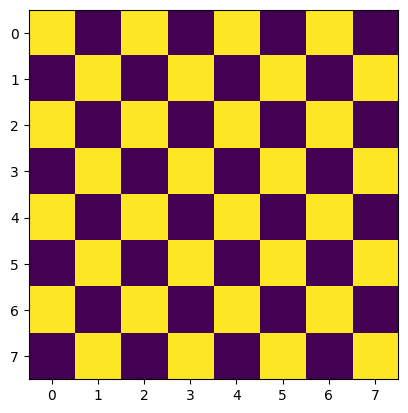

In [46]:
m = 8
n = 8
N = m*n
h, v, d = patrones_balanceados(m, n)
plt.imshow(d)

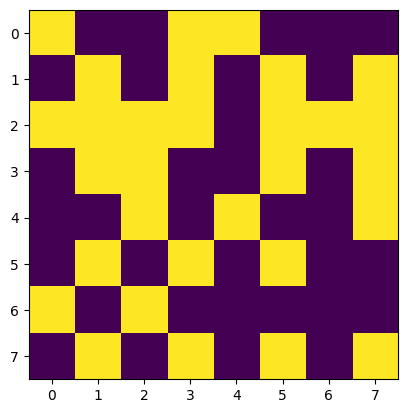

In [47]:
s_ruido = agregar_ruido(np.concat(d), frac=0.25, seed=10)
plt.imshow(np.reshape(s_ruido, (m, n)))

In [48]:
estado = np.concatenate(d).reshape(N, 1)
psi = np.concatenate(d).reshape(1, N)
def pesos_ij(psi,N):
  w = np.zeros((N,N))
  for i in range(N):
    for j in range(N):
      if(i !=j):
        w[i,j] = psi[0][i]*psi[0][j]
  return w/N
w_ij = pesos_ij(psi,N)

In [51]:
def campo_local(w_ij, estado):
  return w_ij@estado

def EnergiaTotal(estado, H):
    return -0.5 * (estado.T @ H).item()


campo = campo_local(w_ij,estado)
ET = EnergiaTotal(estado, campo)
ET

-31.5

In [8]:
s_ruido = s_ruido.reshape(N, 1)
h = campo_local(w_ij, s_ruido)
eT = EnergiaTotal(s_ruido,h)
eT

array([[-7.5]])

In [9]:
def actualizar_neurona(w_ij, s_ruido, N, iteraciones=1000):
    s_ruido_copia = s_ruido.copy()

    for _ in range(iteraciones):
        h = campo_local(w_ij, s_ruido_copia)
        index = np.random.randint(0, N)
        direccion = np.sign(h[index])
        if direccion > 0:
            s_ruido_copia[index] = 1
        else:
            s_ruido_copia[index] = -1

    return s_ruido_copia

s_ruido_final = actualizar_neurona(w_ij, s_ruido, N, 500)
h = campo_local(w_ij, s_ruido_final)
ET_ruido = EnergiaTotal(s_ruido_final,h)
ET_ruido

array([[-31.5]])

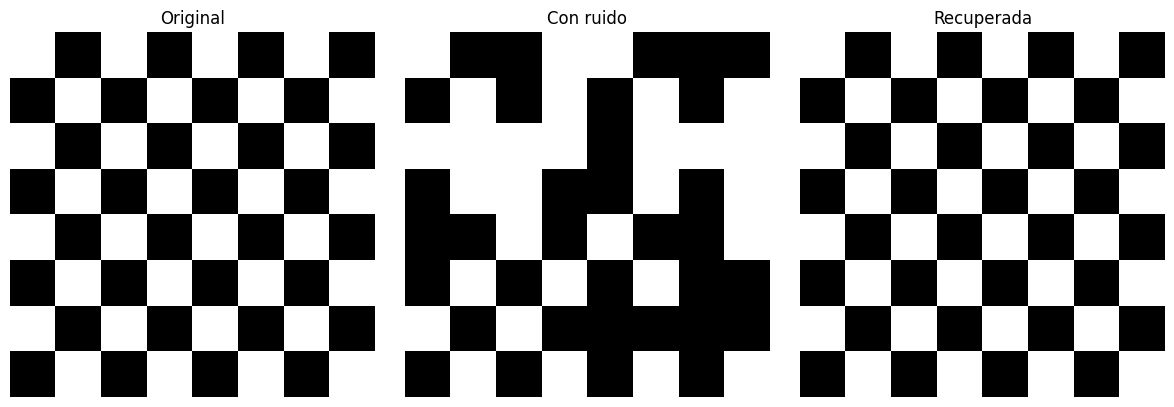

In [10]:
def mostrar_comparacion(original, ruido, recuperada, m, n):
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    # 1. Imagen original
    axes[0].imshow(original, cmap='gray', interpolation='nearest')
    axes[0].set_title('Original')
    axes[0].axis('off')

    # 2. Imagen con ruido
    axes[1].imshow(ruido.reshape(m, n), cmap='gray', interpolation='nearest')
    axes[1].set_title('Con ruido')
    axes[1].axis('off')

    # 3. Imagen recuperada
    axes[2].imshow(recuperada.reshape(m, n), cmap='gray', interpolation='nearest')
    axes[2].set_title('Recuperada')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

mostrar_comparacion(d, s_ruido, s_ruido_final, m, n)

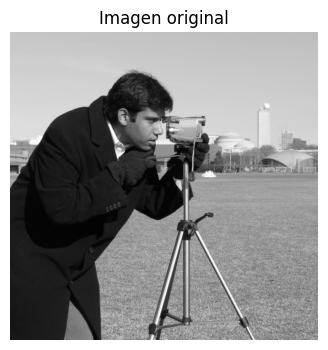

In [11]:
import numpy as np
import matplotlib.pyplot as plt

from skimage import data
from skimage.transform import resize
from skimage.color import rgb2gray

img = data.camera()   # imagen 512x512 en escala de grises

plt.figure(figsize=(4,4))
plt.imshow(img, cmap="gray")
plt.title("Imagen original")
plt.axis("off")
plt.show()

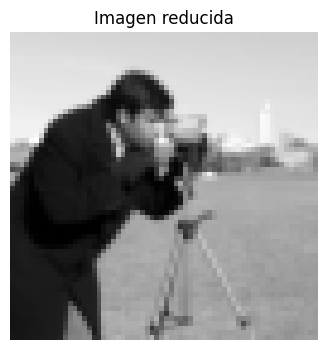

In [19]:
# ============================================================
# Reducir imagen
# ============================================================

n = 64
m = 64
N = n*m

img_small = resize(img, (n, m), anti_aliasing=True)

plt.figure(figsize=(4,4))
plt.imshow(img_small, cmap="gray")
plt.title("Imagen reducida")
plt.axis("off")
plt.show()

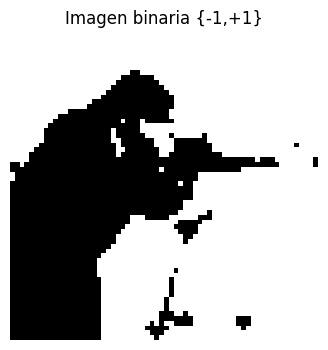

In [20]:
# ============================================================
# Binarización
# ============================================================

threshold = img_small.mean()

img_bin = np.where(img_small > threshold, 1, -1)

plt.figure(figsize=(4,4))
plt.imshow(img_bin, cmap="gray")
plt.title("Imagen binaria {-1,+1}")
plt.axis("off")
plt.show()

In [21]:
img_bin

array([[ 1,  1,  1, ...,  1,  1,  1],
       [ 1,  1,  1, ...,  1,  1,  1],
       [ 1,  1,  1, ...,  1,  1,  1],
       ...,
       [-1, -1, -1, ...,  1,  1,  1],
       [-1, -1, -1, ...,  1,  1,  1],
       [-1, -1, -1, ...,  1,  1,  1]])

In [22]:
# ============================================================
# Ruido
# ============================================================
frac_ruido = 0.3
s_ruido_img = agregar_ruido(np.concat(img_bin), frac= frac_ruido , seed=123)


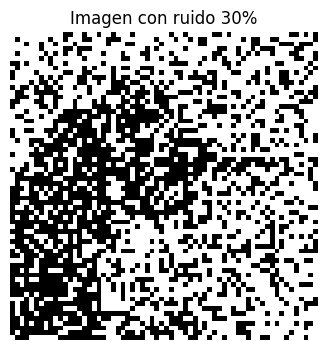

In [23]:
plt.figure(figsize=(4,4))
plt.imshow(s_ruido_img.reshape(n, m), cmap="gray")
plt.title(f"Imagen con ruido {frac_ruido*100:.0f}%")
plt.axis("off")
plt.show()

In [24]:

psi    = img_bin.reshape(1, N)
estado = img_bin.reshape(N, 1)

w_ij = pesos_ij(psi,N)
campo = campo_local(w_ij,estado)
E_total = EnergiaTotal(estado, campo)
E_total

array([[-2047.5]])

In [27]:
h = campo_local(w_ij, s_ruido_img.reshape(N, 1))
eT = EnergiaTotal(s_ruido_img,h)
eT

array([-327.8203125])

In [30]:
s_ruido_final = actualizar_neurona(w_ij, s_ruido_img, N, 50000)
h = campo_local(w_ij, s_ruido_final)
ET_ruido = EnergiaTotal(s_ruido_final,h)
ET_ruido

np.float64(-2047.5)

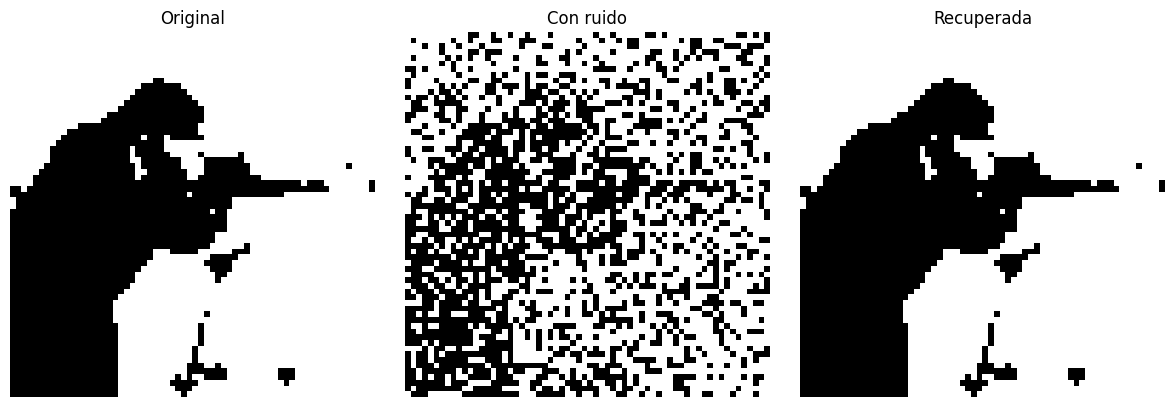

In [31]:
mostrar_comparacion(img_bin, s_ruido_img, s_ruido_final, m, n)

# Múltiples patrones

Ahora vamos a almacenar **varios patrones** en la misma red de Hopfield.
La diferencia con la sección anterior es que los pesos se calculan sumando
la contribución de **todos** los patrones con la regla de Hebb generalizada:

$$w_{ij} = \frac{1}{N} \sum_{\mu=1}^{P} \xi_i^\mu \xi_j^\mu$$

In [52]:
def pesos_ij_multi(patrones, N):
    w = np.zeros((N, N))
    for psi in patrones:
        for i in range(N):
            for j in range(N):
                if i != j:
                    w[i, j] += psi[i] * psi[j]
    return w / N

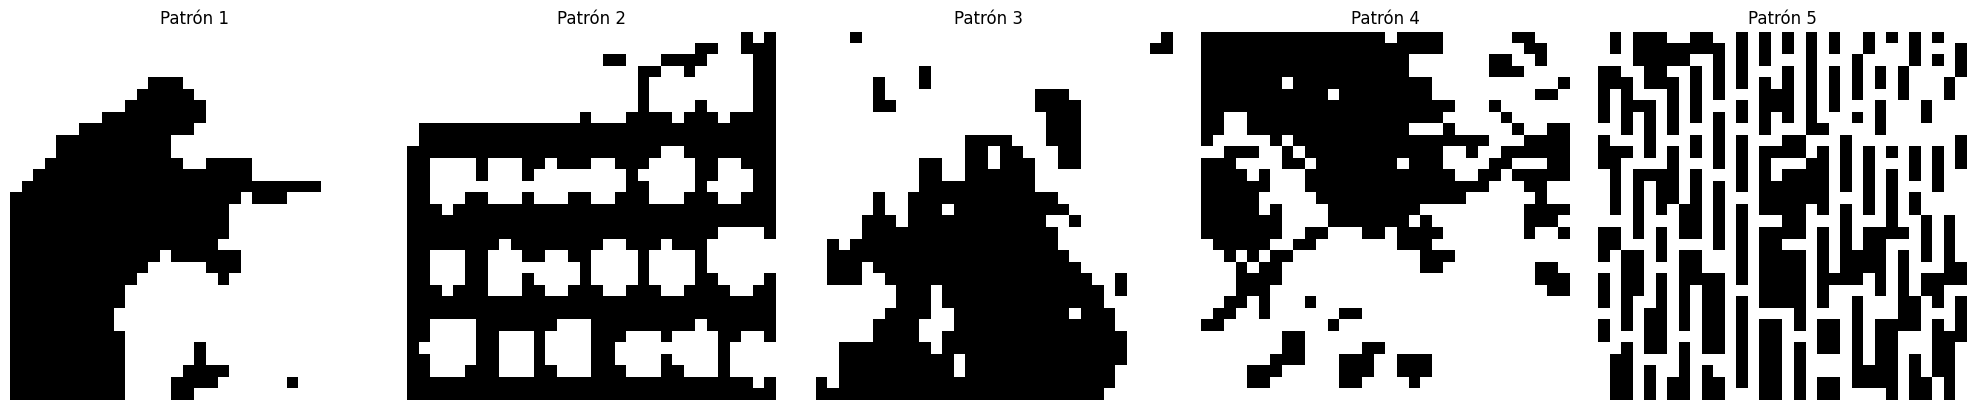

In [53]:
# ============================================================
# Múltiples patrones: cargar y binarizar varias imágenes
# ============================================================

n_multi = 32
m_multi = 32
N_multi = n_multi * m_multi

# Lista de imágenes (todas son 512x512 en escala de grises)
imagenes_raw = [
    data.camera(),
    data.coins(),
    data.moon(),
    data.text(),
    data.brick(),
]

# Binarizar cada imagen usando la MISMA lógica de antes
imagenes_bin = []
for img in imagenes_raw:
    img_small = resize(img, (n_multi, m_multi), anti_aliasing=True)
    threshold = img_small.mean()
    img_bin = np.where(img_small > threshold, 1, -1)
    imagenes_bin.append(img_bin)

# Visualizar todas las imágenes binarias
fig, axes = plt.subplots(1, len(imagenes_bin), figsize=(4 * len(imagenes_bin), 4))
for i, img in enumerate(imagenes_bin):
    axes[i].imshow(img, cmap='gray', interpolation='nearest')
    axes[i].set_title(f'Patrón {i+1}')
    axes[i].axis('off')
plt.tight_layout()
plt.show()

In [54]:
# Aplanar cada imagen a vector 1D
patrones_vectores = [img.ravel() for img in imagenes_bin]

# Calcular pesos con TODOS los patrones
w_ij_multi = pesos_ij_multi(patrones_vectores, N_multi)

In [55]:
print("\nEnergía de cada patrón ORIGINAL:")
for i, psi in enumerate(patrones_vectores):
    estado = psi.reshape(N_multi, 1)
    h = campo_local(w_ij_multi, estado)
    E = EnergiaTotal(estado, h)
    print(f"  Patrón {i+1}: E = {float(E):.2f}")


Energía de cada patrón ORIGINAL:
  Patrón 1: E = -551.22
  Patrón 2: E = -531.45
  Patrón 3: E = -556.23
  Patrón 4: E = -547.04
  Patrón 5: E = -515.73


In [56]:
frac_ruido = 0.25
ruidos = []
recuperadas = []
energias_ruido = []
energias_final = []

for i, psi in enumerate(patrones_vectores):
    print(f"\n--- Patrón {i+1} ---")

    # 1. Añadir ruido (semilla distinta por patrón)
    s_ruido = agregar_ruido(psi, frac=frac_ruido, seed=100 + i)
    ruidos.append(s_ruido)

    # 2. Energía con ruido
    h_ruido = campo_local(w_ij_multi, s_ruido.reshape(N_multi, 1))
    E_ruido = EnergiaTotal(s_ruido.reshape(N_multi, 1), h_ruido)
    energias_ruido.append(float(E_ruido))

    # 3. Recuperar con la red
    s_final = actualizar_neurona(w_ij_multi, s_ruido.reshape(N_multi, 1), N_multi, iteraciones=5000)
    recuperadas.append(s_final.flatten())

    # 4. Energía final
    h_final = campo_local(w_ij_multi, s_final)
    E_final = EnergiaTotal(s_final, h_final)
    energias_final.append(float(E_final))

    print(f"  E (con ruido):  {float(E_ruido):.2f}")
    print(f"  E (recuperado): {float(E_final):.2f}")

    # 5. Verificar aciertos respecto al original
    aciertos = np.sum(s_final.flatten() == psi)
    porcentaje = 100 * aciertos / N_multi
    print(f"  Aciertos: {aciertos}/{N_multi} ({porcentaje:.1f}%)")


--- Patrón 1 ---
  E (con ruido):  -133.28
  E (recuperado): -545.81
  Aciertos: 1022/1024 (99.8%)

--- Patrón 2 ---
  E (con ruido):  -128.90
  E (recuperado): -531.45
  Aciertos: 1024/1024 (100.0%)

--- Patrón 3 ---
  E (con ruido):  -140.62
  E (recuperado): -551.88
  Aciertos: 1021/1024 (99.7%)

--- Patrón 4 ---
  E (con ruido):  -139.29
  E (recuperado): -544.74
  Aciertos: 1023/1024 (99.9%)

--- Patrón 5 ---
  E (con ruido):  -126.34
  E (recuperado): -513.59
  Aciertos: 1023/1024 (99.9%)


In [57]:
def mostrar_comparacion_multi(originales, ruidos, recuperadas, n, m):
    """
    Muestra una fila por patrón: original | con ruido | recuperado.
    """
    num = len(originales)
    fig, axes = plt.subplots(num, 3, figsize=(9, 3 * num))

    # Caso especial: si solo hay 1 patrón, asegurar que axes sea 2D
    if num == 1:
        axes = axes.reshape(1, -1)

    for i in range(num):
        # Columna 1: original
        axes[i, 0].imshow(originales[i].reshape(n, m), cmap='gray', interpolation='nearest')
        axes[i, 0].set_title(f'Original {i+1}')
        axes[i, 0].axis('off')

        # Columna 2: con ruido
        axes[i, 1].imshow(ruidos[i].reshape(n, m), cmap='gray', interpolation='nearest')
        axes[i, 1].set_title(f'Con ruido {i+1}')
        axes[i, 1].axis('off')

        # Columna 3: recuperado
        axes[i, 2].imshow(recuperadas[i].reshape(n, m), cmap='gray', interpolation='nearest')
        axes[i, 2].set_title(f'Recuperado {i+1}')
        axes[i, 2].axis('off')

    plt.tight_layout()
    plt.show()

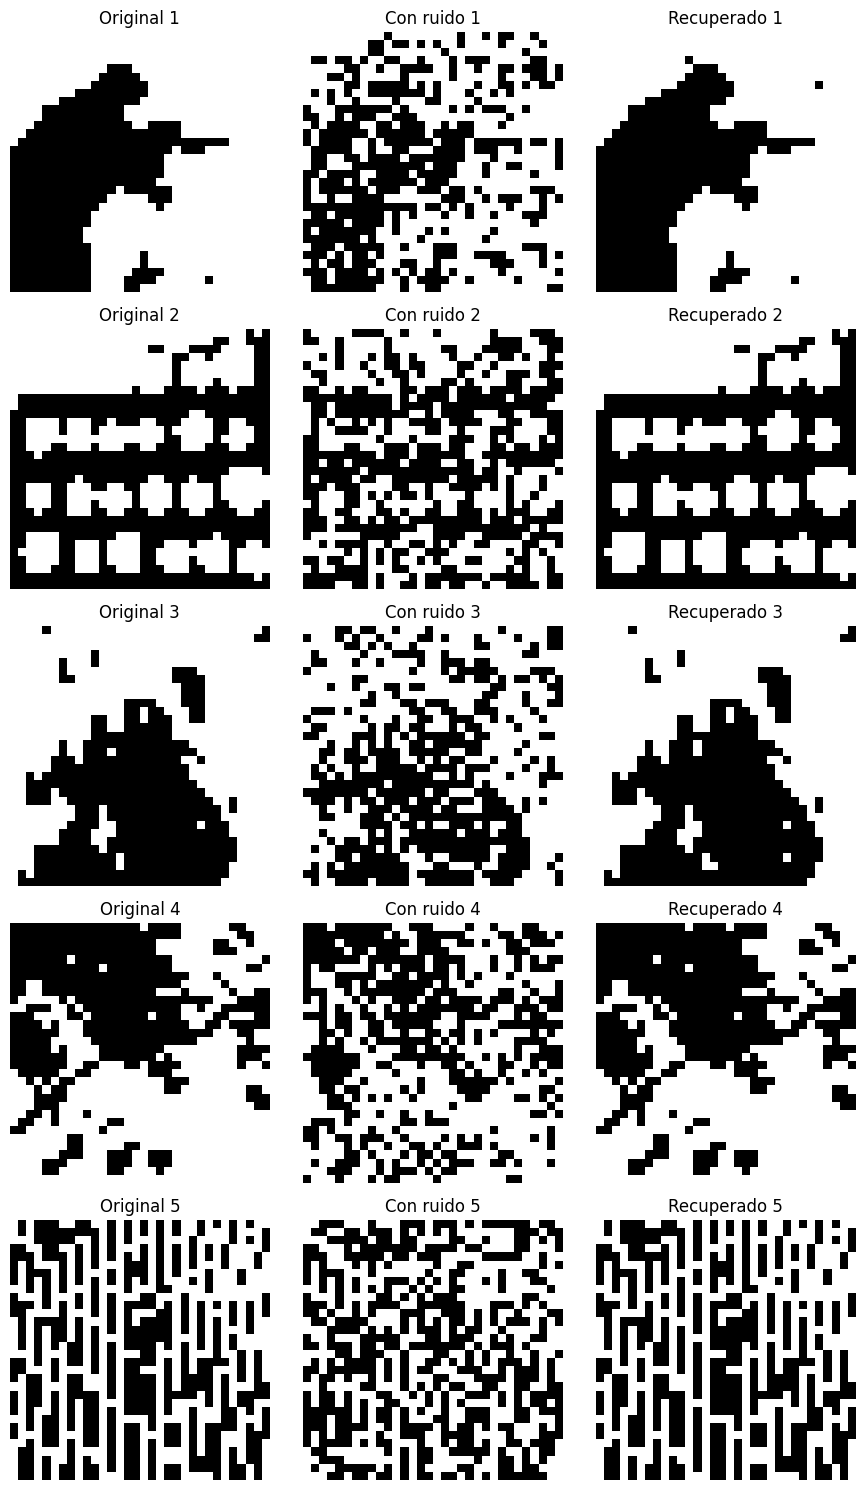

In [58]:
mostrar_comparacion_multi(imagenes_bin, ruidos, recuperadas, n_multi, m_multi)